Task No.1:Load And Data Cleaning:Converting Data Fields & Handle missing /Invalid Values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


#Loading DataSet...
products = pd.read_csv('../Data/products.csv')
inventory = pd.read_csv('../Data/inventory.csv')
sales = pd.read_csv('../Data/sales.csv')
suppliers = pd.read_csv('../Data/suppliers.csv')

#Data Over-Views
products.head()

,Product_ID,Product_Name,Catagory,Unit_Price,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,4.5,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,20.0,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,6.0,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,1.5,Active
4,57-437-1828,Plum,Fruits & Vegetables,4.0,Backordered


In [2]:
inventory.head()

,Product_ID,Stock_Quantity,Reorder_Level,Reorder_Quantity,Date_Received,Expiration_Date,Warehouse_Location
0,29-205-1132,22,72,70,2024-08-16,2024-09-19,48 Del Sol Trail
1,40-681-9981,45,77,2,2024-11-01,2024-05-08,36 3rd Place
2,06-955-3428,30,38,83,2024-08-03,2024-09-22,3296 Walton Court
3,71-594-6552,12,59,62,2024-12-08,2024-04-17,3 Westerfield Crossing
4,57-437-1828,37,30,74,2024-07-03,2024-10-05,15068 Scoville Court


In [3]:
sales.head()

,Product_ID,Sales_Volume,Last_Order_Date
0,29-205-1132,32,2024-06-29
1,40-681-9981,85,2024-05-29
2,06-955-3428,31,2024-06-10
3,71-594-6552,95,2025-02-19
4,57-437-1828,62,2024-10-11


In [4]:
suppliers.head()

,Supplier_ID,Supplier_Name
0,38-037-1699,Jaxnation
1,54-470-2479,Feedmix
2,54-031-2945,Vinder
3,63-492-7603,Brightbean
4,54-226-4308,Topicstorm


In [5]:
#Data Cleaning:Converting Data Fields & Handle missing /Invalid Values

#Converting All Date Columns To Proper Date-Time Format
inventory['Date_Received'] = pd.to_datetime(inventory["Date_Received"])
inventory['Expiration_Date'] = pd.to_datetime(inventory["Expiration_Date"])
sales['Last_Order_Date'] = pd.to_datetime(sales["Last_Order_Date"])


Varifying Format Check


In [6]:
products.head(3)


,Product_ID,Product_Name,Catagory,Unit_Price,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,4.5,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,20.0,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,6.0,Backordered


In [7]:
inventory.head(3)

,Product_ID,Stock_Quantity,Reorder_Level,Reorder_Quantity,Date_Received,Expiration_Date,Warehouse_Location
0,29-205-1132,22,72,70,2024-08-16,2024-09-19,48 Del Sol Trail
1,40-681-9981,45,77,2,2024-11-01,2024-05-08,36 3rd Place
2,06-955-3428,30,38,83,2024-08-03,2024-09-22,3296 Walton Court


In [8]:
sales.head(3)


,Product_ID,Sales_Volume,Last_Order_Date
0,29-205-1132,32,2024-06-29
1,40-681-9981,85,2024-05-29
2,06-955-3428,31,2024-06-10


In [9]:
suppliers.head(3)


,Supplier_ID,Supplier_Name
0,38-037-1699,Jaxnation
1,54-470-2479,Feedmix
2,54-031-2945,Vinder


In [10]:
inventory['Date_Received'][0]

Timestamp('2024-08-16 00:00:00')

Fix Negative  or Missing Stock & Sales Values(Busssines Standard)


In [11]:
inventory["Stock_Quantity"] = inventory["Stock_Quantity"].clip(lower=0)
sales["Sales_Volume"] = sales["Sales_Volume"].clip(lower=0)

MERGE WHOLE DATASET
UseCase:Combine all tables into one unified dataset for complete analysis

In [12]:
df =(products
        .merge(inventory , on="Product_ID")
        .merge(sales, on="Product_ID")
        
        )
df

,Product_ID,Product_Name,Catagory,Unit_Price,Status,Stock_Quantity,Reorder_Level,Reorder_Quantity,Date_Received,Expiration_Date,Warehouse_Location,Sales_Volume,Last_Order_Date
0,29-205-1132,Sushi Rice,Grains & Pulses,4.5,Discontinued,22,72,70,2024-08-16,2024-09-19,48 Del Sol Trail,32,2024-06-29
1,40-681-9981,Arabica Coffee,Beverages,20.0,Discontinued,45,77,2,2024-11-01,2024-05-08,36 3rd Place,85,2024-05-29
2,06-955-3428,Black Rice,Grains & Pulses,6.0,Backordered,30,38,83,2024-08-03,2024-09-22,3296 Walton Court,31,2024-06-10
3,71-594-6552,Long Grain Rice,Grains & Pulses,1.5,Active,12,59,62,2024-12-08,2024-04-17,3 Westerfield Crossing,95,2025-02-19
4,57-437-1828,Plum,Fruits & Vegetables,4.0,Backordered,37,30,74,2024-07-03,2024-10-05,15068 Scoville Court,62,2024-10-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,82-977-7752,Spinach,Fruits & Vegetables,2.5,Active,88,78,17,2024-09-06,2024-11-04,58 Corscot Terrace,58,2024-12-28
986,62-393-9939,Cheddar Cheese,Dairy,9.0,Active,60,9,89,2024-06-01,2024-10-05,5 Oxford Pass,95,2024-06-02
987,31-745-6850,Cabbage,Fruits & Vegetables,0.9,Active,94,90,12,2024-10-03,2024-11-01,081 Jana Lane,98,2024-10-24
988,86-692-2312,Avocado Oil,Oils & Fats,10.0,Active,30,48,52,2024-06-11,2024-04-30,00616 Manitowish Parkway,22,2024-12-07


Taske No.2: MONTHLY SALES TREND ANALYSIS
UseCase: Understand seasonality & demand over time


In [13]:
#Exact month from sales date
sales["Month"] = sales["Last_Order_Date"].dt.to_period("M")

#Join With Category
sales_category = sales.merge(products[["Product_ID", "Catagory"]], on="Product_ID")

#Group By Category-Month
seasonal_category = (
    sales_category
    .groupby(["Catagory", "Month"])["Sales_Volume"]
    .sum()
    .reset_index()
)

#Converting Period:Timestamp for plotting
seasonal_category["Month"] = seasonal_category["Month"].dt.to_timestamp()


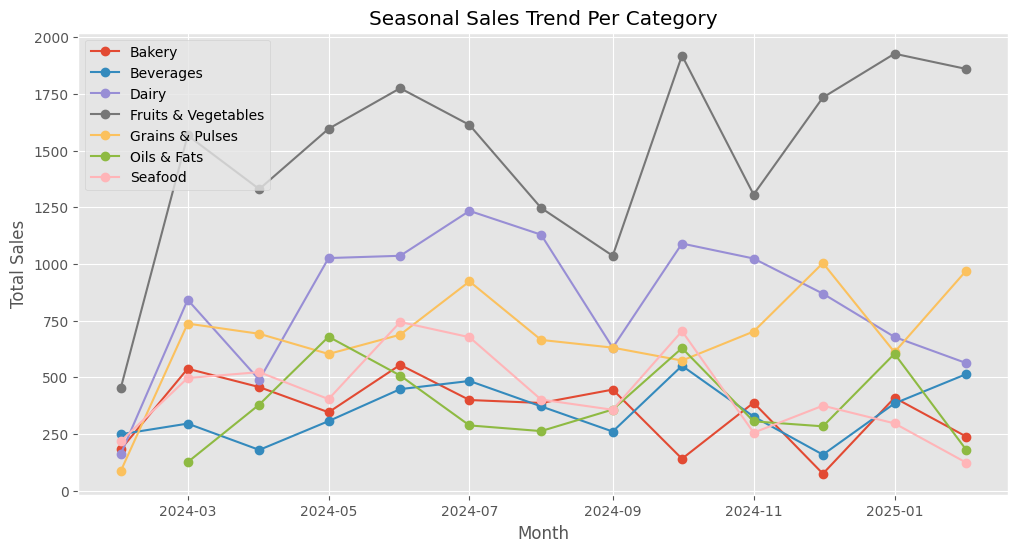

In [14]:
#Visulization:Analyze seasonal sales trends per product category.
plt.figure(figsize=(12,6))
for category in seasonal_category['Catagory'].unique():
    data = seasonal_category[seasonal_category["Catagory"]==category]
    plt.plot(data["Month"],data["Sales_Volume"],marker="o",label=category)

plt.title("Seasonal Sales Trend Per Category")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.legend(loc="upper left")
plt.show()




Task No.3: GROUP Sales By STOCK PRODUCT AND CATEGORY
UseCase:Identify Best & Worst Performing Product Categories.

In [15]:
#Attaching Category Info To Sales
Category_Sales = (
    sales.merge(products[["Product_ID","Catagory"]], on="Product_ID").groupby("Catagory")
    ["Sales_Volume"].sum().sort_values(ascending= False)
)

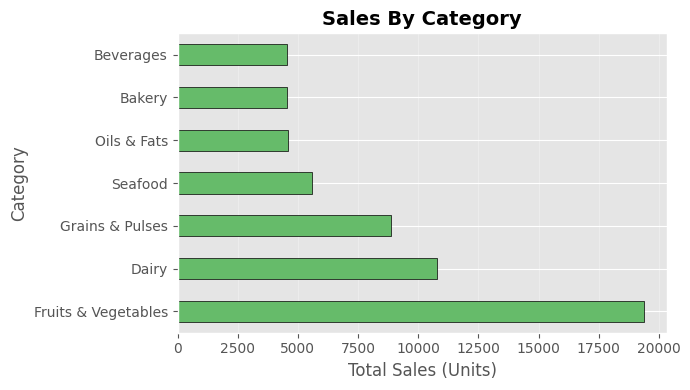

In [16]:
#Visulization:Group By Sales And Category
ax = Category_Sales.plot(
    kind="barh",
    figsize=(7,4),
    color="#66BB6A",
    edgecolor="black"
)

ax.set_title("Sales By Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Sales (Units)")
ax.set_ylabel("Category")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Task No.4: CALCULATE AVERAGE INVENTORY DAYS PER PRODUCTS.
UseCase:Estimate How Long Current Inventory Lasts.

Formula:
Inventory Days = Average Stock / (Total Sales /90 Days) 
*Hint:90 Days = 3 Months  = 1 Quarter (Quarterly Analysis)

In [17]:
#Total Sales Per Product(For 1 Quarter)
total_sales = sales.groupby("Product_ID")["Sales_Volume"].sum()

#Match Stock With Sales
average_stock = inventory.groupby("Product_ID")["Stock_Quantity"].mean()

#Calculate Inventory Days:
#Note:Keep in mind vro :{error call:Avoid divide-by-zero}
inventory_days = average_stock/(total_sales/90)
inventory_days.replace([float("inf")],None,inplace=True)

inventory_days.head()

Product_ID
00-119-8780     92.307692
00-215-7434     21.355932
00-357-2313     37.500000
00-366-9496     42.857143
00-405-7428    173.571429
dtype: float64

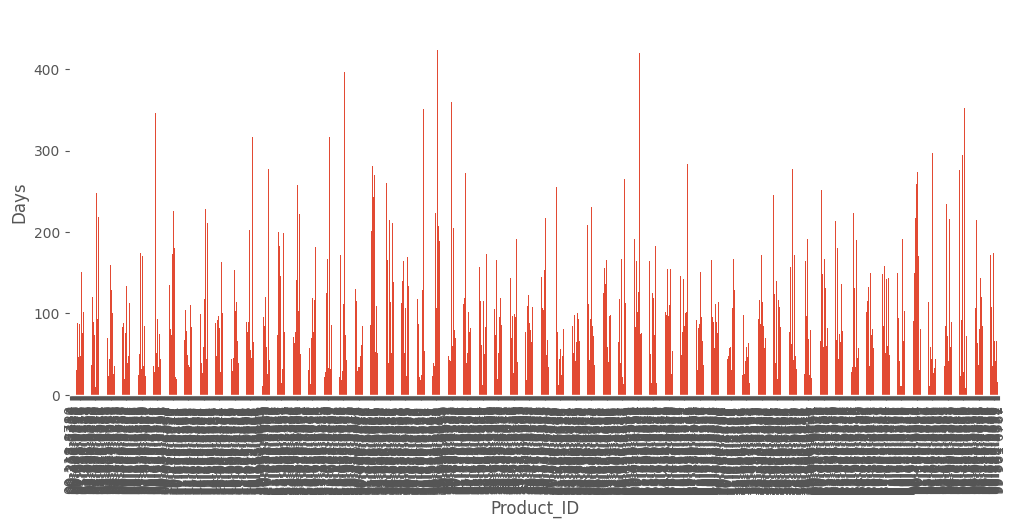

In [18]:

#Visulization Just For Analysis Sastisfaction Purpose
inventory_days.plot(kind="bar", figsize=(12,5))
plt.title="Inventory Days per Product"
plt.ylabel("Days")
plt.show()


Task No.5: IDENTIFY HIGH-DEMAND AND LOW-DEMAND PRODUCTS.
UseCase:Classify Products Based On Sales Distribution
Based On: Quantile-Based Binning(*Data Processing Techniques) :(Industry Standard Approach)


In [19]:
total_sales_prod = sales.groupby("Product_ID")["Sales_Volume"].sum()
#pd.quct:it Dive data into equal parts cut:top 25%, next 25%, lower 25%… etc
#i have Use q = 3: For 3 parts Cut:low,medium,high
# Lower 33% : Low Demand
# Middle 33% : Medium Demand
# Top 33% :High Demand

demand_level = pd.qcut(
    total_sales_prod, q =3,
    labels = ["Low Demand","Medium Demand","High Demand"]

)

demand_level.head()

Product_ID
00-119-8780       Low Demand
00-215-7434    Medium Demand
00-357-2313       Low Demand
00-366-9496    Medium Demand
00-405-7428       Low Demand
Name: Sales_Volume, dtype: category
Categories (3, object): ['Low Demand' < 'Medium Demand' < 'High Demand']

Task No.6: ANALYZE SUPPLIER DELIVERY TIMES AND DELAYS
UseCase:This analysis identifies how frequently products and categories are restocked, 
        helping optimize inventory planning even when supplier mapping is unavailable.
        This analysis identifies how frequently products and categories are restocked, 
        helping optimize inventory planning even when supplier mapping is unavailable.

In [20]:
#Delivery Frequency per Product
#UseCase:Determines how frequently each product is restocked by measuring the gap between consecutive inventory receipts.


# Sort records by Product_ID and date
inv_sorted = inventory.sort_values(['Product_ID','Date_Received'])

#Delivery gap Between Consecutive  entries
inv_sorted['Delivery_Gap_Days'] = (
    inv_sorted.groupby('Product_ID')['Date_Received']
    .diff()
    .dt.days
)

inv_sorted.head()

,Product_ID,Stock_Quantity,Reorder_Level,Reorder_Quantity,Date_Received,Expiration_Date,Warehouse_Location,Delivery_Gap_Days
278,00-119-8780,40,81,78,2025-02-17,2024-03-04,21 Sunbrook Court,NaN
207,00-215-7434,14,63,74,2024-04-28,2024-11-28,389 Ridgeway Park,NaN
180,00-357-2313,10,86,23,2024-06-29,2024-12-13,0 Oxford Crossing,NaN
826,00-366-9496,30,66,28,2024-08-09,2024-12-28,898 Rowland Trail,NaN
296,00-405-7428,81,74,45,2025-01-20,2025-01-12,42 Mallory Court,NaN


In [21]:
#Average Delivery Gap per Product
#Identify which items are slow-moving in the supply chain
avg_delivery_gap = (
    inv_sorted.groupby('Product_ID')["Delivery_Gap_Days"]
    .mean()
    .reset_index()
    .rename(columns={'Delivery_Gap_Days':'Avg_Delivery_Gap_Days'})

)

avg_delivery_gap.head()



#Note:
# Since Supplier_ID is not linked to inventory/products in this dataset,
# delivery analysis is performed at the product level. We calculate the 
# number of days between consecutive inventory receipts for each product.
# This shows how frequently each product gets restocked.

,Product_ID,Avg_Delivery_Gap_Days
0,00-119-8780,NaN
1,00-215-7434,NaN
2,00-357-2313,NaN
3,00-366-9496,NaN
4,00-405-7428,NaN


In [22]:
# Category-Level Delivery Frequency
# Which category receives stock more frequently

inv_cat = inv_sorted.merge(products[['Product_ID','Catagory']],on='Product_ID')
category_gap = (
    inv_cat.groupby('Catagory')['Delivery_Gap_Days']
    .mean()
    .reset_index()
    .rename(columns={'Delivery_Gap_Days':'Avg_Category_Delivery_Gap'})
    
)
category_gap


,Catagory,Avg_Category_Delivery_Gap
0,Bakery,NaN
1,Beverages,NaN
2,Dairy,NaN
3,Fruits & Vegetables,NaN
4,Grains & Pulses,NaN
5,Oils & Fats,NaN
6,Seafood,NaN


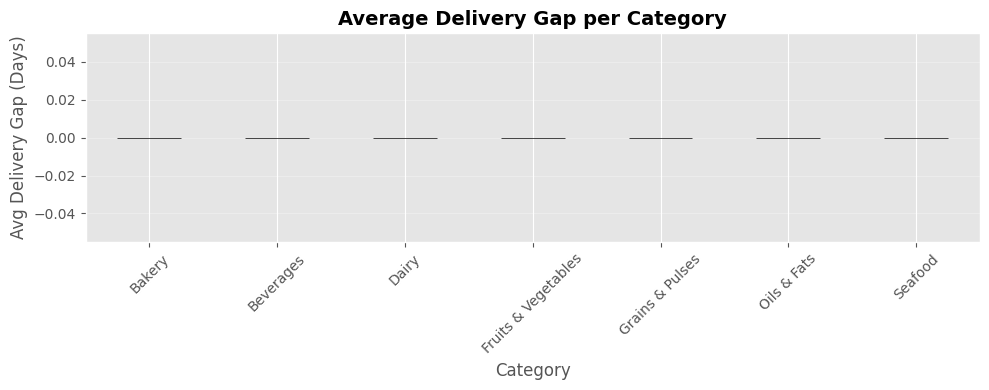

In [23]:
#Visualization — Average Delivery Gap per Category
ax = category_gap.plot(
    x="Catagory",
    y="Avg_Category_Delivery_Gap",
    kind="bar",
    figsize=(10,4),
    color="#42A5F5",
    edgecolor="black",
    legend=False
)

ax.set_title("Average Delivery Gap per Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Avg Delivery Gap (Days)")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()



Task No.7: PERFORM STOCK-OUT PREDICTION ANALYSIS.


In [24]:
#If
# Stock_Quantity <= Reorder_Level
# Product is at risk of stock-out.


In [25]:
# Flag Low_Stocl Production
df['Stock_Risk'] = (df['Stock_Quantity']<=df['Reorder_Level'].astype(int))
df[['Product_ID','Stock_Quantity','Reorder_Level','Stock_Risk']].head()

,Product_ID,Stock_Quantity,Reorder_Level,Stock_Risk
0,29-205-1132,22,72,True
1,40-681-9981,45,77,True
2,06-955-3428,30,38,True
3,71-594-6552,12,59,True
4,57-437-1828,37,30,False


In [26]:
# Stock-Out Summary
stockout_summary = (
    df.groupby('Catagory')['Stock_Risk']
    .sum()
    .reset_index()
    .rename(columns = {'Stock_Risk':'Stockout_Count'})
)
stockout_summary

,Catagory,Stockout_Count
0,Bakery,35
1,Beverages,36
2,Dairy,81
3,Fruits & Vegetables,150
4,Grains & Pulses,85
5,Oils & Fats,40
6,Seafood,38


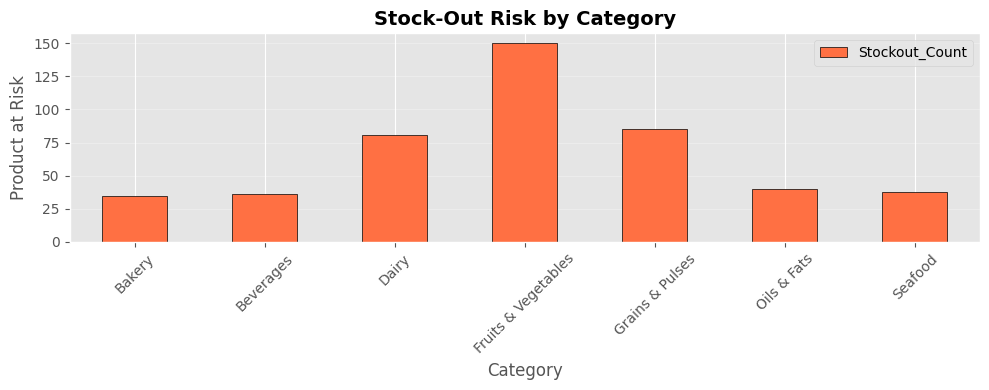

In [27]:
# Visualization of Stock-Out
ax = stockout_summary.plot(
    x='Catagory',
    y='Stockout_Count',
    kind='bar',
    figsize=(10,4),
    color="#FF7043",      
    edgecolor="black"
)

ax.set_title("Stock-Out Risk by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Product at Risk")

plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()



Task no.8:VISULIZE MONTHLY SALES VS STOCK LEVELS


In [28]:
#Computing Monthly Stock

monthly_stock = (
    inventory.groupby(inventory['Date_Received'].dt.to_period('M'))['Stock_Quantity']
    .mean()
    .reset_index()
)
monthly_stock['Month'] = monthly_stock['Date_Received'].dt.to_timestamp()


In [29]:
#Computing Monthly Sales
monthly_sales = (
    sales.groupby(sales['Last_Order_Date'].dt.to_period('M'))['Sales_Volume']
    .sum()
    .reset_index()
)
monthly_sales['Month'] = monthly_sales['Last_Order_Date'].dt.to_timestamp()

In [30]:
#Merging Both
month_compare = monthly_sales.merge(
    monthly_stock[['Month','Stock_Quantity']],
    on="Month",
    how = 'left'

)
month_compare

,Last_Order_Date,Sales_Volume,Month,Stock_Quantity
0,2024-02,1347,2024-02-01,62.714286
1,2024-03,4603,2024-03-01,55.317073
2,2024-04,4051,2024-04-01,56.988372
3,2024-05,4961,2024-05-01,54.567901
4,2024-06,5754,2024-06-01,55.193182
5,2024-07,5619,2024-07-01,53.923913
6,2024-08,4465,2024-08-01,56.534884
7,2024-09,3720,2024-09-01,57.246154
8,2024-10,5608,2024-10-01,52.808081
9,2024-11,4345,2024-11-01,56.135135


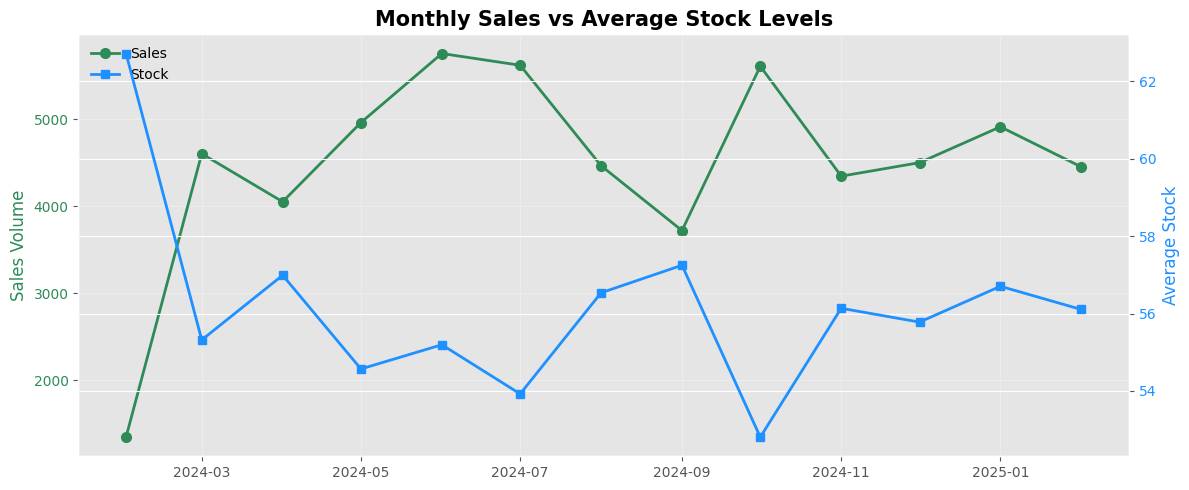

In [31]:
# Monthly Sales vs Average Stock Levels Visualization
# This chart compares monthly sales volumes with corresponding 
# stock availability using a dual-axis line plot.


# Creating the figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot monthly sales volume (Primary Axis)
ax1.plot(
    month_compare["Month"],
    month_compare["Sales_Volume"],
    color="#2E8B57",
    marker="o",
    markersize=7,
    linewidth=2,
    label="Sales"
)

# Primary Y-axis label and styling
ax1.set_ylabel("Sales Volume", color="#2E8B57")
ax1.tick_params(axis='y', labelcolor="#2E8B57")

# Creating a secondary Y-axis for stock quantity
ax2 = ax1.twinx()

# Plot monthly stock quantity (Secondary Axis)
ax2.plot(
    month_compare["Month"],
    month_compare["Stock_Quantity"],
    color="#1E90FF",
    marker="s",
    markersize=6,
    linewidth=2,
    label="Stock"
)

# Secondary Y-axis label and styling
ax2.set_ylabel("Average Stock", color="#1E90FF")
ax2.tick_params(axis='y', labelcolor="#1E90FF")


ax1.set_title("Monthly Sales vs Average Stock Levels", fontsize=15, fontweight="bold")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.xticks(rotation=45)
ax1.grid(alpha=0.3)
plt.tight_layout()

plt.show()